# Deteccion de anomalías

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Mejores parámetros: {'contamination': 0.05, 'max_samples': 'auto', 'n_estimators': 50, 'random_state': 42}

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

    Anomalía       0.88      1.00      0.94        15
      Normal       1.00      0.99      1.00       300

    accuracy                           0.99       315
   macro avg       0.94      1.00      0.97       315
weighted avg       0.99      0.99      0.99       315



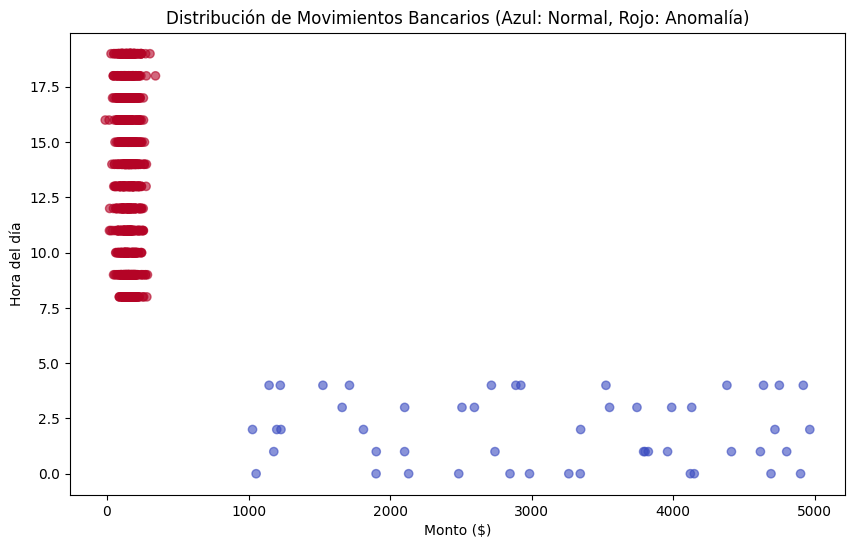

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, f1_score, make_scorer
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. GENERACIÓN DE DATASET SINTÉTICO
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 1000
n_anomalies = 50

# Transacciones normales (Montos bajos, horario laboral)
normal_amounts = np.random.normal(loc=150, scale=50, size=n_samples)
normal_hours = np.random.randint(8, 20, size=n_samples) 

# Anomalías (Montos muy altos, horarios de madrugada)
anomaly_amounts = np.random.uniform(1000, 5000, size=n_anomalies) 
anomaly_hours = np.random.randint(0, 5, size=n_anomalies) 

# Consolidación de datos
amounts = np.concatenate([normal_amounts, anomaly_amounts])
hours = np.concatenate([normal_hours, anomaly_hours])
# Etiquetas: 1 para normal, -1 para anomalía (estándar de scikit-learn para outliers)
labels = np.concatenate([np.ones(n_samples), -1 * np.ones(n_anomalies)]) 

df = pd.DataFrame({
    'Monto': amounts,
    'Hora': hours,
    'Es_Anomalia': labels
})

# Mezclar el dataset
df = df.sample(frac=1).reset_index(drop=True)

# ---------------------------------------------------------
# 2. PREPROCESAMIENTO
# ---------------------------------------------------------
# Escalamos los datos ya que Isolation Forest se beneficia de magnitudes comparables
X = df[['Monto', 'Hora']]
y_true = df['Es_Anomalia']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en entrenamiento y prueba (estratificado para mantener proporción de anomalías)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_true, test_size=0.3, random_state=42, stratify=y_true
)

# ---------------------------------------------------------
# 3. FINE-TUNING CON GRID SEARCH
# ---------------------------------------------------------
# Definimos el espacio de búsqueda de hiperparámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_samples': ['auto', 0.8, 0.5],
    'contamination': [0.03, 0.05, 0.1], # Proporción esperada de anomalías
    'random_state': [42]
}

# Usamos F1-Score enfocándonos en la clase -1 (anomalías) como métrica de optimización
f1_anomaly_scorer = make_scorer(f1_score, pos_label=-1)

grid_search = GridSearchCV(
    IsolationForest(),
    param_grid,
    scoring=f1_anomaly_scorer,
    cv=3,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Mejor modelo seleccionado
best_model = grid_search.best_estimator_
print(f"Mejores parámetros: {grid_search.best_params_}")

# ---------------------------------------------------------
# 4. EVALUACIÓN DE MÉTRICAS
# ---------------------------------------------------------
y_pred = best_model.predict(X_test)

print("\n--- Reporte de Clasificación ---")
# Mapeamos -1 a 'Anomalía' y 1 a 'Normal' para el reporte
print(classification_report(y_test, y_pred, target_names=['Anomalía', 'Normal']))

# Visualización simple
plt.figure(figsize=(10, 6))
plt.scatter(df['Monto'], df['Hora'], c=df['Es_Anomalia'], cmap='coolwarm', alpha=0.6)
plt.title('Distribución de Movimientos Bancarios (Azul: Normal, Rojo: Anomalía)')
plt.xlabel('Monto ($)')
plt.ylabel('Hora del día')
plt.show()

## Análisis Financiero: Detección de Anomalías con DBSCAN
Este notebook tiene como objetivo identificar transacciones sospechosas (fraude o errores) en un conjunto de datos financieros. A diferencia de K-Means, DBSCAN es ideal para esto porque no asume que los grupos tienen formas circulares y identifica automáticamente los puntos en zonas de baja densidad como "ruido" (anomalías).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# Configuración estética
sns.set_theme(style="whitegrid")


### 2. Generación de Datos Sintéticos (Escenario Financiero)
Simularemos transacciones bancarias con dos variables: Monto y Frecuencia de Transacciones por día. La mayoría de los usuarios tienen un comportamiento normal, pero simularemos algunos "atípicos".

In [5]:
# Generar datos normales (usuarios legítimos)
np.random.seed(42)
normal_data = np.random.normal(loc=[50, 5], scale=[15, 2], size=(300, 2))

# Generar anomalías (ej: montos muy altos o frecuencias inusuales)
anomalies = np.array([
    [200, 1],   # Monto muy alto, poca frecuencia
    [250, 15],  # Monto altísimo, frecuencia altísima (posible bot/ataque)
    [10, 25],   # Monto bajo, pero frecuencia extremadamente alta
    [180, 8],
    [220, 2]
])

# Combinar en un DataFrame
data = np.vstack([normal_data, anomalies])
df = pd.DataFrame(data, columns=['Monto', 'Frecuencia_Diaria'])

print(f"Total de registros: {len(df)}")
df.head()



Total de registros: 305


,Monto,Frecuencia_Diaria
0,57.450712,4.723471
1,59.715328,8.046060
2,46.487699,4.531726
3,73.688192,6.534869
4,42.957884,6.085120


### 3. Análisis Exploratorio y Preprocesamiento
DBSCAN se basa en distancias euclidianas, por lo que es obligatorio escalar los datos para que el Monto (escala 0-250) no domine a la Frecuencia (escala 0-25).

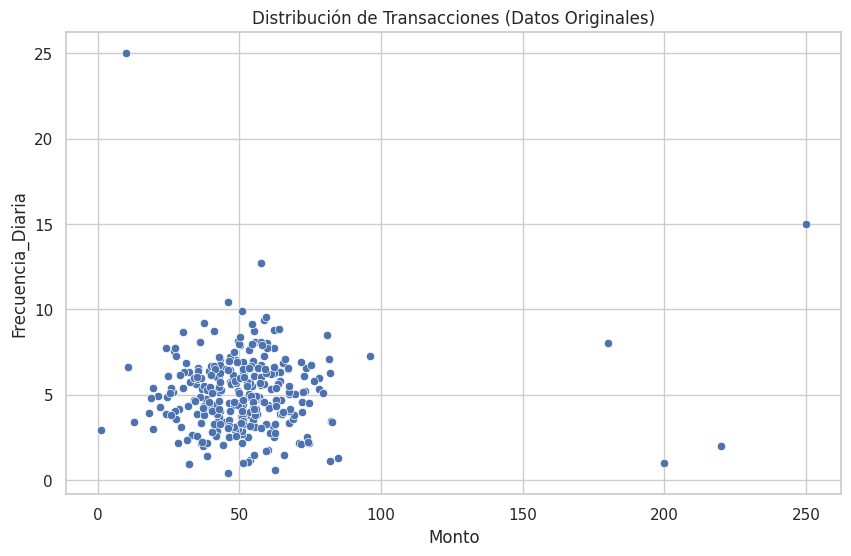

In [6]:
# Escalado de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Visualización inicial
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Monto'], y=df['Frecuencia_Diaria'])
plt.title("Distribución de Transacciones (Datos Originales)")
plt.show()

### 4. Manejo de Hiperparámetros
DBSCAN requiere dos parámetros clave:
- min_samples: Cantidad mínima de puntos para formar una zona densa. (Regla: $D \times 2$ donde $D$ es el número de dimensiones).
- eps (Épsilon): El radio máximo para considerar a un vecino.

**Técnica del "Codo" para encontrar eps**

Calculamos la distancia al vecino más cercano para cada punto y las graficamos en orden ascendente. El punto de máxima curvatura es nuestro eps ideal.

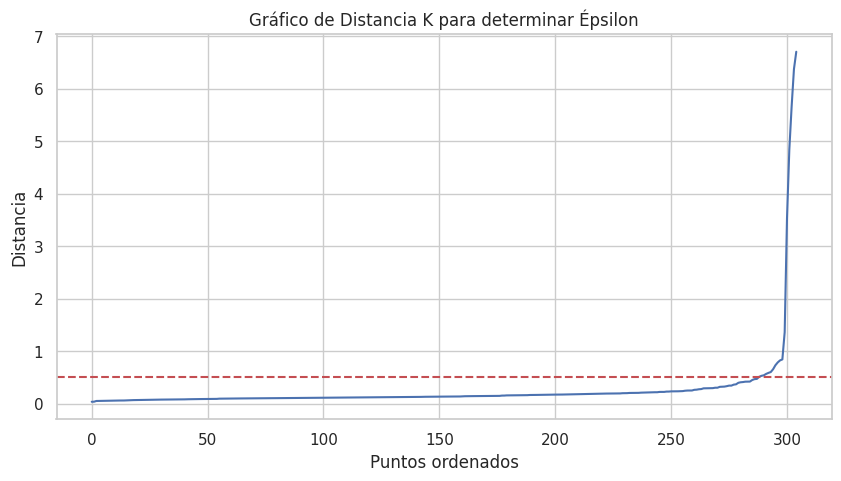

In [7]:

# Calcular distancias al k-ésimo vecino (k = min_samples)
min_samples = 4
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ordenar y graficar
distances = np.sort(distances[:, min_samples-1], axis=0)
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title("Gráfico de Distancia K para determinar Épsilon")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia")
plt.axhline(y=0.5, color='r', linestyle='--') # Ejemplo de punto de corte
plt.show()



### 5. Entrenamiento del Modelo y Predicción
Usaremos un eps basado en el gráfico anterior (ej: 0.5) y min_samples=4.

In [8]:
# Aplicar DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=4)
clusters = dbscan.fit_predict(X_scaled)

# Los puntos etiquetados como -1 son las anomalías detectadas
df['Cluster'] = clusters
df['Es_Anomalia'] = df['Cluster'] == -1

n_anomalias = df['Es_Anomalia'].sum()
print(f"Anomalías detectadas: {n_anomalias}")




Anomalías detectadas: 13


### 6. Métricas de Evaluación
En la detección de anomalías sin etiquetas previas, usamos métricas de cohesión y separación:

- Silhouette Score: Mide qué tan bien están agrupados los datos. (Excluyendo anomalías para ver la calidad de los clusters normales).

- Ratio de Outliers: Proporción de datos marcados como sospechosos.

In [9]:
# Silhouette Score para los puntos que NO son ruido
mask = clusters != -1
labels_sin_ruido = clusters[mask]
unique_labels = np.unique(labels_sin_ruido)

if unique_labels.size >= 2 and labels_sin_ruido.shape[0] > unique_labels.size:
    score = silhouette_score(X_scaled[mask], labels_sin_ruido)
    print(f"Silhouette Score (Clusters Normales): {score:.3f}")
else:
    print("Silhouette Score no calculado: DBSCAN generó menos de 2 clusters válidos (sin ruido).")

# Proporción de anomalías
print(f"Porcentaje de anomalías: {(n_anomalias/len(df))*100:.2f}%")

Silhouette Score no calculado: DBSCAN generó menos de 2 clusters válidos (sin ruido).
Porcentaje de anomalías: 4.26%


### 7. Visualización de Resultados (Etapa de Análisis)
Identificamos visualmente los grupos legítimos y las alertas de fraude.

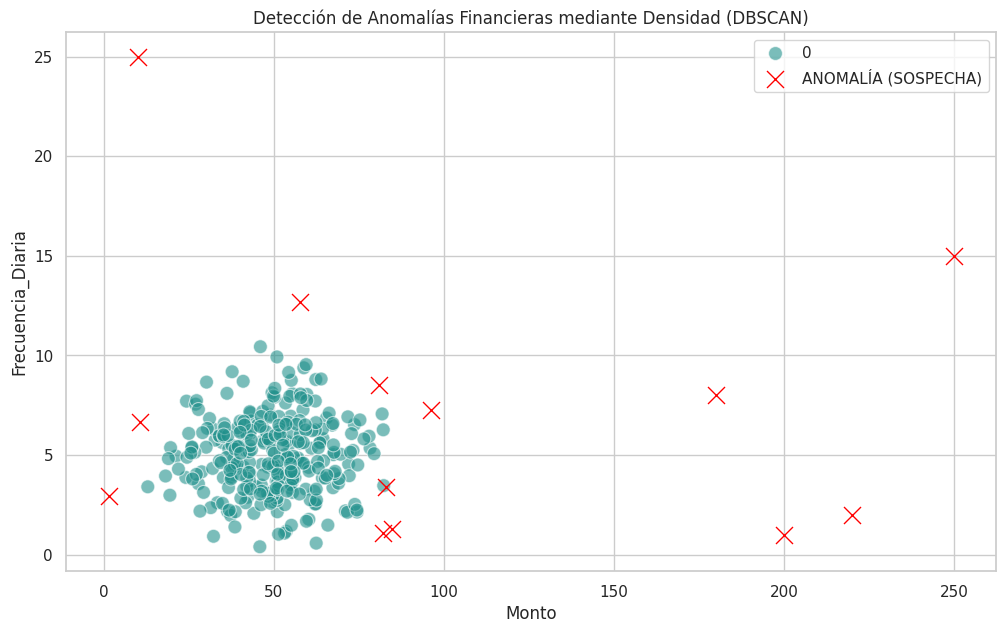

In [10]:
plt.figure(figsize=(12, 7))

# Graficar puntos normales
sns.scatterplot(data=df[df['Cluster'] != -1], x='Monto', y='Frecuencia_Diaria', 
                hue='Cluster', palette='viridis', s=100, alpha=0.6)

# Resaltar anomalías en rojo
sns.scatterplot(data=df[df['Cluster'] == -1], x='Monto', y='Frecuencia_Diaria', 
                color='red', marker='x', s=150, label='ANOMALÍA (SOSPECHA)')

plt.title("Detección de Anomalías Financieras mediante Densidad (DBSCAN)")
plt.legend()
plt.show()